# Multiple Regression

In [1]:
path_data = '../../data/'

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
np.set_printoptions(suppress=True)

In the previous section, we fit a multiple regression with scikit-learn. In this section, we build one from scratch to see how the slopes are found, using a new data set with real home sales. Predicting a numerical quantity is called regression, and a commonly used method to use multiple attributes for regression is called *multiple linear regression*.

## Home Prices

The following dataset of house prices and attributes was collected over several years for the city of Ames, Iowa. A [description of the dataset appears online](http://ww2.amstat.org/publications/jse/v19n3/decock.pdf). We will focus only a subset of the columns. We will try to predict the sale price column from the other columns.

```{contents}
:local:
:depth: 2
```


In [2]:
def standard_units(any_numbers):
    "Convert any array of numbers to standard units."
    return (any_numbers - np.mean(any_numbers))/np.std(any_numbers)  

def correlation(t, x, y):
    return np.mean(standard_units(t[x])*standard_units(t[y])).item(0)

In [3]:
all_sales = pd.read_csv(path_data + 'house.csv')
# len(all_sales)
all_sales

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [4]:
all_sales.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [5]:
sales1 = all_sales[all_sales['Bldg Type'] == '1Fam']
sales2 = sales1[sales1['Sale Condition'] == 'Normal']

sales = sales2[['SalePrice', '1st Flr SF', '2nd Flr SF', 
    'Total Bsmt SF', 'Garage Area', 
    'Wood Deck SF', 'Open Porch SF', 'Lot Area', 
    'Year Built', 'Yr Sold']]

sales = sales.sort_values(by=['SalePrice'])

len(sales)

2002

A histogram of sale prices shows a large amount of variability and a distribution that is clearly not normal. A long tail to the right contains a few houses that had very high prices. The short left tail does not contain any houses that sold for less than $35,000.

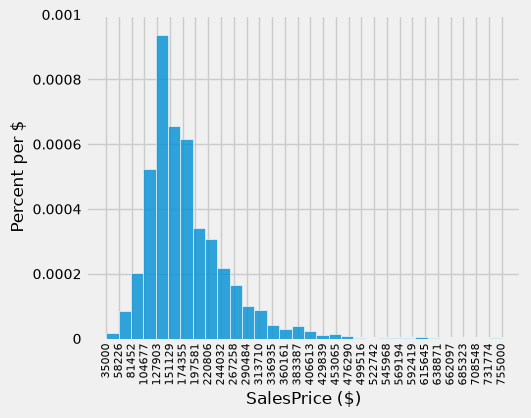

In [6]:
fig, ax = plt.subplots(figsize=(5,4))
ax.hist(sales['SalePrice'], bins=32, density=True, alpha=0.8, ec='white', zorder=5)

unit = '$'
y_label = 'Percent per ' + (unit if unit else 'unit')
x_label = 'SalesPrice ($)' 
plt.ylabel(y_label, fontsize=12)
plt.xlabel(x_label, fontsize=12)

x_min, x_max = sales['SalePrice'].min(), sales['SalePrice'].max()   ### multiple assignment
ax.set_xticks(np.linspace(x_min, x_max+.01, 32))
# ax.set_xticks(np.linspace(0, 800000, 9))

plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=10)

y_vals = ax.get_yticks()
ax.set_yticks(y_vals)
ax.set_yticklabels(['{:g}'.format(x * 100) for x in y_vals])

plt.title('');
plt.show()

### Correlation

No single attribute is sufficient to predict the sale price. For example, the area of first floor, measured in square feet, correlates with sale price but only explains some of its variability.

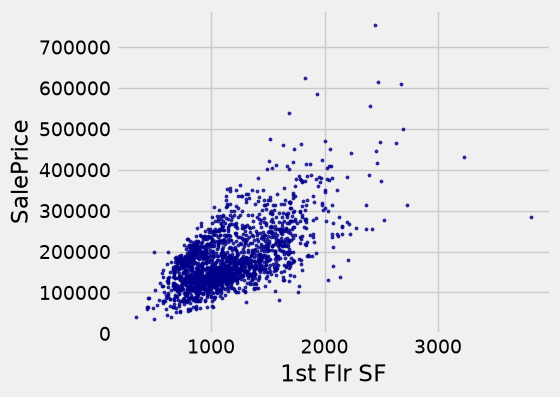

In [7]:
fig, ax = plt.subplots(figsize=(5,4))

ax.scatter(
    sales['1st Flr SF'], 
    sales['SalePrice'],   
    color='darkblue', 
    alpha=0.8,
    s=5
)

x_label = '1st Flr SF'
y_label = 'SalePrice'

plt.ylabel(y_label)
plt.xlabel(x_label)
plt.show()

In [8]:
correlation(sales, 'SalePrice', '1st Flr SF')

0.6424662541030225

In fact, none of the individual attributes have a correlation with sale price that is above 0.7 (except for the sale price itself).

In [9]:
for label in sales.columns:
    print('Correlation of', label, 'and SalePrice:\t', correlation(sales, label, 'SalePrice'))

Correlation of SalePrice and SalePrice:	 1.0
Correlation of 1st Flr SF and SalePrice:	 0.6424662541030225
Correlation of 2nd Flr SF and SalePrice:	 0.3575218942800824
Correlation of Total Bsmt SF and SalePrice:	 0.652978626757169
Correlation of Garage Area and SalePrice:	 0.6385944852520442
Correlation of Wood Deck SF and SalePrice:	 0.3526986661950491
Correlation of Open Porch SF and SalePrice:	 0.3369094170263733
Correlation of Lot Area and SalePrice:	 0.29082345511576946
Correlation of Year Built and SalePrice:	 0.5651647537135916
Correlation of Yr Sold and SalePrice:	 0.025948579080721124


However, combining attributes can provide higher correlation. In particular, if we sum the first floor and second floor areas, the result has a higher correlation than any single attribute alone.

In [10]:
sales_copy = sales.copy()
both_floors = sales_copy.iloc[:,1] + sales_copy.iloc[:,2]

sales_copy['Both Floors'] = both_floors
correlation(sales_copy, 'SalePrice', 'Both Floors')

0.7821920556134877

In [11]:
# sales_copy.iloc[:,2]
# sales_copy['2nd Flr SF']

This high correlation indicates that we should try to use more than one attribute to predict the sale price. In a dataset with multiple observed attributes and a single numerical value to be predicted (the sale price in this case), multiple linear regression can be an effective technique.

## Multiple Linear Regression 

In multiple linear regression, a numerical output is predicted from numerical input attributes by multiplying each attribute value by a different slope, then summing the results. In this example, the slope for the `1st Flr SF` would represent the dollars per square foot of area on the first floor of the house that should be used in our prediction. 

Before we begin prediction, we split our data randomly into a training and test set of equal size.

### Train/Test split

In [12]:
sales_copy = sales.copy()
train = sales_copy.sample(1001, replace=False, random_state=13)
test = sales_copy.drop(train.index)

print(f"{len(train)} training and {len(test)} test instances.")

1001 training and 1001 test instances.


### Function for train/test split

In [13]:
def split(self, k):
    if not 1 <= k <= (len(self) - 1):
        raise ValueError("Invalid value of k. k must be between 1 and the"
                         "number of rows - 1")

    rows = np.random.default_rng(13).permutation(len(self))     ### random shuffle of indices (seeded)
    first = self.take(rows[:k])                 ### first k random rows → training set
    rest = self.take(rows[k:])                  ### remaining random rows → test set

    return (first, rest)                          ### return a single tuple object

train, test = split(sales, 1001)

print(len(train), 'training and', len(test), 'test instances.')

1001 training and 1001 test instances.


### The scikit learn way
We could employ the scikit learn [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#sklearn-model-selection-train-test-split) function to determine the train, test split.

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split

train, test = train_test_split(sales_copy, test_size=0.5, random_state=13)

print(len(train), 'training and', len(test), 'test instances.')

1001 training and 1001 test instances.


The slopes in multiple regression is an array that has one slope value for each attribute in an example. Predicting the sale price involves multiplying each attribute by the slope and summing the result.

Notice that this model has **no intercept**. The `LinearRegression` model in the previous section fit an intercept $\beta_0$ plus one slope per attribute; `predict` below only multiplies and sums, so a house whose attributes were all 0 would be predicted to cost \$0. We keep the model this simple so that the search for the best model only has to find slopes. One side effect: `Year Built` and `Yr Sold` are close to 2000 for every house, so their slopes end up doing part of an intercept's job, setting the overall price level. Read those two slopes with that in mind.

In [15]:
def predict(slopes, row):
    return sum(slopes * np.array(row))

example_row1 = test.drop(columns=['SalePrice'])
example_row = example_row1.iloc[0]

print('Predicting sale price for:')
print(example_row)

example_slopes = np.random.default_rng(13).normal(10, 1, len(example_row))

print('\nUsing slopes:\n', example_slopes)

print('\nResult:', predict(example_slopes, example_row))

Predicting sale price for:
1st Flr SF        848.0
2nd Flr SF        580.0
Total Bsmt SF     712.0
Garage Area       576.0
Wood Deck SF      264.0
Open Porch SF       0.0
Lot Area         6451.0
Year Built       1900.0
Yr Sold          2006.0
Name: 2641, dtype: float64

Using slopes:
 [11.82675656  6.92166809 10.95806398 10.06963723 11.31825002 10.38562925
 11.82725863 10.03174376  9.48377056]

Result: 145016.32993816028


The result is an estimated sale price, which can be compared to the actual sale price to assess whether the slopes provide accurate predictions. Since the `example_slopes` above were chosen at random, we should not expect them to provide accurate predictions at all.

In [16]:
print('Actual sale price:', test['SalePrice'].iloc[0])
print('Predicted sale price using random slopes:', predict(example_slopes, example_row))

Actual sale price: 139900
Predicted sale price using random slopes: 145016.32993816028


### Least Squares Regression

The next step in performing multiple regression is to define the least squares objective. We perform the prediction for each row in the training set, and then compute the root mean squared error (RMSE) of the predictions from the actual prices.

In [17]:
train_prices = train.iloc[:,0]
train1 = train.copy()
train_attributes = train1.drop(train1.columns[0], axis=1)

def rmse(slopes, attributes, prices):
    errors = []
    for i in np.arange(len(prices)):
        predicted = predict(slopes, attributes.iloc[i])
        actual = prices.iloc[i]
        errors.append((predicted - actual) ** 2)
    return np.mean(errors) ** 0.5

def rmse_train(slopes):
    return rmse(slopes, train_attributes, train_prices)

print('RMSE of all training examples using random slopes:', rmse_train(example_slopes))

RMSE of all training examples using random slopes: 88139.7377326553


Finally, we use the `minimize` function to find the slopes with the lowest RMSE. Since the function we want to minimize, `rmse_train`, takes an array instead of a number, we must pass the `array=True` argument to `minimize`. When this argument is used, `minimize` also requires an initial guess of the slopes so that it knows the dimension of the input array. Finally, to speed up optimization, we indicate that `rmse_train` is a smooth function using the `smooth=True` attribute. Computation of the best slopes may take several minutes.

[scipy optimize.minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html)

In [18]:
from scipy import optimize

def minimize(f, start=None, smooth=False, log=None, array=False, **vargs):
    """Minimize a function f of one or more arguments.
    Args:
        f: A function that takes numbers and returns a number
        start: A starting value or list of starting values
        smooth: Whether to assume that f is smooth and use first-order info
        log: Logging function called on the result of optimization (e.g. print)
        vargs: Other named arguments passed to scipy.optimize.minimize
    Returns either:
        (a) the minimizing argument of a one-argument function
        (b) an array of minimizing arguments of a multi-argument function
    """
    if start is None:
        assert not array, "Please pass starting values explicitly when array=True"
        arg_count = f.__code__.co_argcount
        assert arg_count > 0, "Please pass starting values explicitly for variadic functions"
        start = [0] * arg_count
    if not hasattr(start, '__len__'):
        start = [start]

    if array:
        objective = f
    else:
        @functools.wraps(f)
        def objective(args):
            return f(*args)

    if not smooth and 'method' not in vargs:
        vargs['method'] = 'Powell'
    result = optimize.minimize(objective, start, **vargs)
    if log is not None:
        log(result)
    if len(start) == 1:
        return result.x.item(0)
    else:
        return result.x

In [19]:
best_slopes = minimize(rmse_train, start=example_slopes, smooth=True, array=True)
 
train_df = pd.DataFrame(columns=[train_attributes.columns])

train_df.loc[0] = best_slopes

print('The best slopes for the training set:')

train_df

The best slopes for the training set:


,1st Flr SF,2nd Flr SF,Total Bsmt SF,Garage Area,Wood Deck SF,Open Porch SF,Lot Area,Year Built,Yr Sold
0,70.284761,78.14222,52.249434,49.680101,40.073921,19.604064,0.685828,429.425241,-429.130683


In [20]:
print(f'RMSE of all training examples using the best slopes: {rmse_train(best_slopes)}')

RMSE of all training examples using the best slopes: 31838.18490661393


### Interpreting Multiple Regression 

Let's interpret these results. The best slopes give us a method for estimating the price of a house from its attributes. A square foot of area on the first floor is worth about `$70` (the first slope), while one on the second floor is worth about `$78` (the second slope). The `Year Built` and `Yr Sold` slopes are almost equal and opposite (about +429 and -429). Because the model has no intercept, read them together: they add up to about -429 × (`Yr Sold` - `Year Built`), so each year of a house's age at sale lowers the predicted price by roughly \$429.

The RMSE of around `$32,000` means that our best linear prediction of the sale price based on all of the attributes is off by around \$32,000 on the training set, on average.  We find a similar error when predicting prices on the test set, which indicates that our prediction method will generalize to other samples from the same population.

In [21]:
test_prices = test.iloc[:,0]

test_attributes = test.drop(test.columns[0], axis=1)
test_attributes

,1st Flr SF,2nd Flr SF,Total Bsmt SF,Garage Area,Wood Deck SF,Open Porch SF,Lot Area,Year Built,Yr Sold
2641,848,580,712.0,576.0,264,0,6451,1900,2006
1858,1094,761,528.0,512.0,113,100,9600,1976,2007
438,1743,0,1739.0,927.0,168,45,10367,2008,2009
796,1148,568,768.0,281.0,0,0,11409,1949,2009
1057,1950,0,1950.0,706.0,156,207,14418,2007,2008
...,...,...,...,...,...,...,...,...,...
1581,1256,0,1256.0,578.0,282,0,18265,1986,2008
976,1404,0,1188.0,504.0,0,16,13383,1969,2009
2774,1494,0,1479.0,576.0,168,27,9236,1997,2006
2737,1836,1836,1836.0,836.0,684,80,19800,1935,2006


Now we use the `best_slopes` from the training set in the test.

In [22]:
test_prices = test.iloc[:,0]
test_attributes = test.drop(test.columns[0], axis=1)

def rmse_test(slopes):
    return rmse(slopes, test_attributes, test_prices)

rmse_linear = rmse_test(best_slopes)
print('Test set RMSE for multiple linear regression:', rmse_linear)

Test set RMSE for multiple linear regression: 30564.429912311512


If the predictions were perfect, then a scatter plot of the predicted and actual values would be a straight line with slope 1. We see that most dots fall near that line, but there is some error in the predictions.

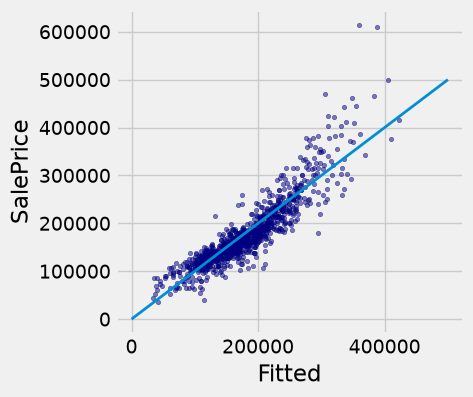

In [23]:
def fit(row):
    return sum(best_slopes * np.array(row))

test['Fitted'] = test_attributes.apply(fit, axis=1)

fig, ax = plt.subplots(figsize=(4,4))

ax.scatter(
    test['Fitted'], 
    test['SalePrice'],   
    color='navy', 
    alpha=0.5,
    s=10
)

x_label = 'Fitted'
y_label = 'SalePrice'

plt.ylabel(y_label)
plt.xlabel(x_label)

plt.plot([0, 5e5], [0, 5e5], lw=2)

plt.show()

A residual plot for multiple regression typically compares the errors (residuals) to the actual values of the predicted variable. We see in the residual plot below that we have systematically underestimated the value of expensive houses, shown by the many positive residual values on the right side of the graph.

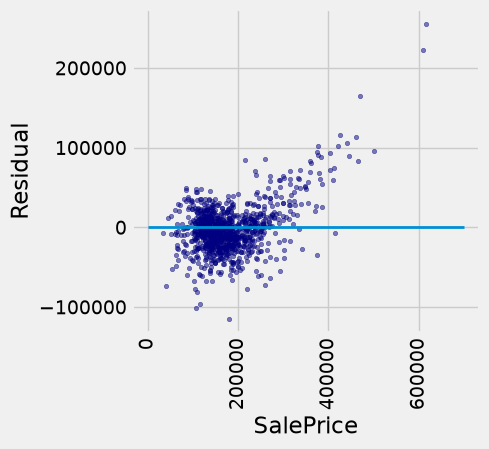

In [24]:
test['Residual'] = test_prices-test_attributes.apply(fit, axis=1)

fig, ax = plt.subplots(figsize=(4,4))

ax.scatter(
    test['SalePrice'], 
    test['Residual'],   
    color='navy', 
    alpha=0.5,
    s=10
)

x_label = 'SalePrice'

y_label = 'Residual'

plt.ylabel(y_label)

plt.xlabel(x_label)

plt.xticks(rotation=90)

plt.plot([0, 7e5], [0, 0], lw=2)

plt.show()

As with simple linear regression, interpreting the result of a predictor is at least as important as making predictions. There are many lessons about interpreting multiple regression that are not included in this textbook. A natural next step after completing this text would be to study linear modeling and regression in further depth.

## Nearest Neighbors for Regression

Another approach to predicting the sale price of a house is to use the price of similar houses. This *nearest neighbor* approach finds the houses in the training set whose attributes are closest to the house we want to price, and averages their prices. To speed up computation, we will only use the attributes that had the highest correlation with the sale price in our original analysis.

In [25]:
train_nn = train.iloc[:, [0, 1, 2, 3, 4, 8]]
test_nn = test.iloc[:, [0, 1, 2, 3, 4, 8]]
train_nn

,SalePrice,1st Flr SF,2nd Flr SF,Total Bsmt SF,Garage Area,Year Built
717,160000,1090,917,917.0,357.0,1900
1189,215000,1620,0,1620.0,578.0,1967
1218,153000,1118,0,1118.0,264.0,1960
2328,275000,1742,0,1742.0,564.0,1985
841,138000,990,0,990.0,480.0,1994
...,...,...,...,...,...,...
1432,144000,1099,0,1099.0,352.0,1995
2158,219500,847,1081,847.0,434.0,2003
193,87000,765,0,765.0,200.0,1925
1491,108000,996,0,996.0,0.0,1940


To find the closest houses, we compute the distance between houses using their attributes, leaving out `'SalePrice'`, the value we want to predict. The five nearest neighbors of the first test row are shown below.

In [26]:
def distance(pt1, pt2):
    """The distance between two points, represented as arrays."""
    return np.sqrt(np.sum((pt1 - pt2) ** 2))
    
def row_distance(row1, row2):
    """The distance between two rows of a table."""
    return distance(np.array(row1), np.array(row2))

def distances(training, example, output):
    """Compute the distance from example for each row in training."""
    dists = []
    attributes = training.drop(columns=[output])
    for row in range(len(attributes)):
        dists.append(row_distance(attributes.iloc[row], example))
    training['Distance'] = dists
    #print(training)
    return training

def closest(training, example, k, output):
    """Return a table of the k closest neighbors to example."""
    distance = distances(training, example, output).sort_values(by=['Distance']).take(np.arange(k))
    return distance

train_nn_A = train_nn.copy()
example_nn_row = test_nn.drop(test_nn.columns[0], axis=1).iloc[0]
closest(train_nn_A, example_nn_row, 5, 'SalePrice')

,SalePrice,1st Flr SF,2nd Flr SF,Total Bsmt SF,Garage Area,Year Built,Distance
190,140750,868,602,738.0,624.0,1922,65.939366
188,125500,741,622,622.0,528.0,1910,154.003247
1348,128000,751,611,611.0,502.0,1920,162.625336
2013,126000,861,548,861.0,528.0,1938,164.748293
2878,108000,897,439,637.0,570.0,1920,168.353794


One simple method for predicting the price is to average the prices of the nearest neighbors.

In [27]:
example_nn_row

1st Flr SF        848.0
2nd Flr SF        580.0
Total Bsmt SF     712.0
Garage Area       576.0
Year Built       1900.0
Name: 2641, dtype: float64

In [28]:
def predict_nn(example):
    """Predict the price as the average price of the 5 nearest neighbors."""
    train_nn_B = train_nn.copy()
    
    col_sales_price = closest(train_nn_B, example, 5, 'SalePrice')
    return np.average(col_sales_price['SalePrice'])

predict_nn(example_nn_row)

np.float64(125650.0)

Finally, we can inspect whether our prediction is close to the true sale price for our one test example. Looks reasonable!

In [29]:
print('Actual sale price:', test_nn['SalePrice'].iloc[0])
print('Predicted sale price using nearest neighbors:', predict_nn(example_nn_row))

Actual sale price: 139900
Predicted sale price using nearest neighbors: 125650.0


### Evaluation

To evaluate the performance of this approach for the whole test set, we apply `predict_nn` to each test example, then compute the root mean squared error of the predictions. Computation of the predictions may take several minutes.

In [30]:
def predict_nn(example):
    """Predict the price as the average price of the 5 nearest neighbors."""
    train_nn_B = train_nn.copy()
    
    col_sales_price = closest(train_nn_B, example, 5, 'SalePrice')
    return np.average(col_sales_price['SalePrice']).item(0)

predict_nn(example_nn_row)

125650.0

In [31]:
test_nn_C = test_nn.copy()
test_nn_drop = test_nn_C.drop(columns=['SalePrice'])

nn_test_predictions = test_nn_drop.apply(predict_nn, axis=1)
rmse_nn = np.mean((test_prices - nn_test_predictions) ** 2) ** 0.5

print('Test set RMSE for multiple linear regression: ', rmse_linear)
print('Test set RMSE for nearest neighbor regression:', rmse_nn)

Test set RMSE for multiple linear regression:  30564.429912311512
Test set RMSE for nearest neighbor regression: 31595.90871162731


For these data, the errors of the two techniques are quite similar! For different data sets, one technique might outperform another. By computing the RMSE of both techniques on the same data, we can compare methods fairly. One note of caution: the difference in performance might not be due to the technique at all; it might be due to the random variation due to sampling the training and test sets in the first place.

Finally, we can draw a residual plot for these predictions. Like the linear model, nearest neighbors underestimates the prices of the most expensive houses: the residuals grow as the sale price increases. Few training houses are that expensive, so the nearest neighbors of an expensive house tend to be cheaper houses. 

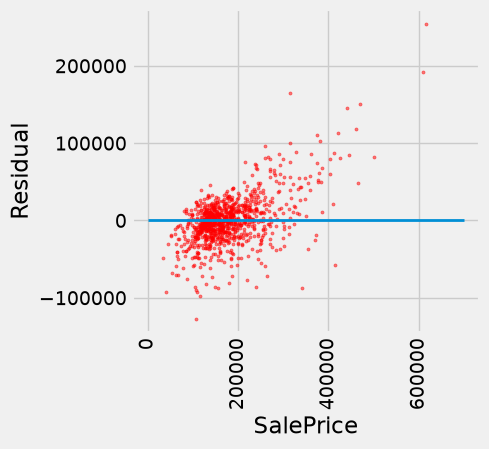

In [32]:
test['Residual'] = test_prices-nn_test_predictions

fig, ax = plt.subplots(figsize=(4,4))

ax.scatter(
    test['SalePrice'], 
    test['Residual'],   
    color='red', 
    alpha=0.5,
    s=5
)

x_label = 'SalePrice'
y_label = 'Residual'
plt.ylabel(y_label)
plt.xlabel(x_label)
plt.xticks(rotation=90)
plt.plot([0, 7e5], [0, 0], lw=2)
plt.show()


## Section Practice

Use this short exercise to check the main workflow from this section.


In [33]:
### Exercise: Practice Multiple Regression
# A model produced the predictions and actual values below.
# Calculate each error as actual minus predicted. Then print the mean absolute error.
predicted = [98, 105, 110, 120]
actual = [100, 102, 114, 119]
### Your code starts here




### Your code ends here


In [34]:
### Solution
predicted = [98, 105, 110, 120]
actual = [100, 102, 114, 119]
errors = [a - p for a, p in zip(actual, predicted)]
mean_absolute_error = sum(abs(error) for error in errors) / len(errors)
print(errors)
print(mean_absolute_error)


[2, -3, 4, -1]
2.5


In [35]:
### Exercise: Section Practice 1
# book-rule-sparse-practice
# A manager wants a short check on the chapter section named below.
# Create a list named steps with three actions: identify decision, choose metric, explain result.
# Print exactly these three lines, using the existing section_focus value:
# Section: Home Prices
# Steps: 3
# First step: identify decision
section_focus = 'Home Prices'

### Your code starts here.

### Your code ends here.


In [36]:
section_focus = 'Home Prices'
steps = ["identify decision", "choose metric", "explain result"]
print("Section:", section_focus)
print("Steps:", len(steps))
print("First step:", steps[0])


Section: Home Prices
Steps: 3
First step: identify decision


In [37]:
### Exercise: Section Practice 2
# book-rule-sparse-practice
# The chapter uses the section headings to organize related ideas.
# Store the three provided terms in a list named representative_terms.
# Print exactly these two lines:
# Terms: Home, Prices, Multiple
# Term count: 3
provided_terms = ['Home', 'Prices', 'Multiple']

### Your code starts here.

### Your code ends here.


In [38]:
representative_terms = ['Home', 'Prices', 'Multiple']
print("Terms:", ", ".join(representative_terms))
print("Term count:", len(representative_terms))


Terms: Home, Prices, Multiple
Term count: 3
